In [1]:
from google.colab import files
df = uploaded = files.upload()

Saving sales_raw.csv to sales_raw.csv


In [2]:
import pandas as pd

df = pd.read_csv("sales_raw.csv")



In [3]:
raw_count = len(df)

In [4]:
df.head()

,sale_id,transaction_date,product_code,cust_id,qty,unit_price
0,1,2023-04-13,P007,29.0,3.0,18.97
1,2,2023-12-15,P002,20.0,3.0,$54.36
2,3,2023-09-28,P001,15.0,1.0,$34.26
3,4,2023-04-17,P0012,15.0,6.0,56.02
4,5,2023-03-13,P0011,24.0,2.0,$32.39


In [5]:
print("Total records: ", len(df))

Total records:  515


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sale_id           515 non-null    int64  
 1   transaction_date  515 non-null    object 
 2   product_code      515 non-null    object 
 3   cust_id           512 non-null    float64
 4   qty               402 non-null    float64
 5   unit_price        515 non-null    object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.3+ KB


In [7]:
df.isnull().sum()

,0
sale_id,0
transaction_date,0
product_code,0
cust_id,3
qty,113
unit_price,0


In [8]:
df[df.duplicated()]

,sale_id,transaction_date,product_code,cust_id,qty,unit_price
500,19,2023-09-15,P003,19.0,NaN,53.51
501,362,2023-04-24,P007,21.0,2.0,65.67
502,105,2023-06-12,P0012,5.0,NaN,27.86
503,5,2023-03-13,P0011,24.0,2.0,$32.39
504,157,2023-03-27,P0010,18.0,NaN,58.89
505,351,2023-11-19,P999,19.0,2.0,44.51
506,33,2023-07-07,P003,19.0,4.0,$76.2
507,206,2023-04-23,P999,28.0,7.0,42.48
508,82,2023-08-01,P007,5.0,7.0,80.4
509,415,2023-04-18,P003,11.0,5.0,-12.34


In [9]:
df.describe()

,sale_id,cust_id,qty
count,515.000000,512.000000,402.000000
mean,249.452427,15.382812,3.985075
std,145.382279,8.827657,2.035784
min,1.000000,1.000000,1.000000
25%,122.500000,8.000000,2.000000
50%,249.000000,15.000000,4.000000
75%,374.500000,23.000000,6.000000
max,500.000000,30.000000,7.000000


In [10]:
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'
)


In [11]:
df['qty'] = pd.to_numeric(
    df['qty'],
    errors='coerce'
)


In [12]:
df['unit_price'] = (
    df['unit_price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
)

df['unit_price'] = pd.to_numeric(
    df['unit_price'],
    errors='coerce'
)


In [13]:
df = df.dropna(subset=['transaction_date', 'qty', 'unit_price'])

In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 402 entries, 0 to 514
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sale_id           402 non-null    int64         
 1   transaction_date  402 non-null    datetime64[ns]
 2   product_code      402 non-null    object        
 3   cust_id           400 non-null    float64       
 4   qty               402 non-null    float64       
 5   unit_price        402 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 22.0+ KB


In [15]:
# Impute missing quantity with median quantity
df['qty'] = df['qty'].fillna(df['qty'].median())

# Impute missing unit_price with median price
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())


In [16]:
# Replace zero quantities with median quantity
df.loc[df['qty'] == 0, 'qty'] = df['qty'].median()

# Drop negative quantities
df = df[df['qty'] > 0]


In [17]:
# Replace zero prices with median unit_price
df.loc[df['unit_price'] == 0, 'unit_price'] = df['unit_price'].median()

# Drop negative prices
df = df[df['unit_price'] > 0]


In [18]:
df.describe()


,sale_id,transaction_date,cust_id,qty,unit_price
count,377.000000,377,376.000000,377.00000,377.000000
mean,236.230769,2023-07-04 22:35:58.090185728,15.311170,3.94695,123.629204
min,1.000000,2023-01-01 00:00:00,1.000000,1.00000,10.140000
25%,117.000000,2023-04-13 00:00:00,8.000000,2.00000,41.220000
50%,234.000000,2023-07-07 00:00:00,15.000000,4.00000,72.320000
75%,346.000000,2023-10-02 00:00:00,23.000000,6.00000,101.960000
max,500.000000,2023-12-30 00:00:00,30.000000,7.00000,844.530000
std,140.067109,NaN,8.907614,2.03097,173.893177


In [19]:
df.duplicated(subset=['sale_id']).sum()


np.int64(8)

In [20]:
df[df.duplicated(subset=['sale_id'], keep=False)].sort_values('sale_id')


,sale_id,transaction_date,product_code,cust_id,qty,unit_price
4,5,2023-03-13,P0011,24.0,2.0,32.39
503,5,2023-03-13,P0011,24.0,2.0,32.39
506,33,2023-07-07,P003,19.0,4.0,76.20
32,33,2023-07-07,P003,19.0,4.0,76.20
65,66,2023-04-16,P008,8.0,4.0,49.52
514,66,2023-04-16,P008,8.0,4.0,49.52
508,82,2023-08-01,P007,5.0,7.0,80.40
81,82,2023-08-01,P007,5.0,7.0,80.40
512,96,2023-12-11,P001,30.0,4.0,37.96
95,96,2023-12-11,P001,30.0,4.0,37.96


In [21]:
df = df.drop_duplicates(subset=['sale_id'], keep='first')


In [22]:
df['sale_id'].duplicated().sum()


np.int64(0)

In [23]:
fact_sales = df.copy()


In [24]:
fact_sales.loc[:, 'transaction_date'] = pd.to_datetime(fact_sales['transaction_date'])
fact_sales.loc[:, 'qty'] = fact_sales['qty'].astype(int)
fact_sales.loc[:, 'unit_price'] = fact_sales['unit_price'].astype(float)


In [25]:
fact_sales['revenue'] = fact_sales['qty'] * fact_sales['unit_price']


In [28]:
fact_sales = fact_sales[
    [
        'sale_id',
        'transaction_date',
        'product_code',
        'cust_id',
        'qty',
        'unit_price',
        'revenue'
    ]
]



In [29]:
fact_sales.info()


<class 'pandas.core.frame.DataFrame'>
Index: 369 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sale_id           369 non-null    int64         
 1   transaction_date  369 non-null    datetime64[ns]
 2   product_code      369 non-null    object        
 3   cust_id           368 non-null    float64       
 4   qty               369 non-null    float64       
 5   unit_price        369 non-null    float64       
 6   revenue           369 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 23.1+ KB


In [30]:
fact_sales.head()


,sale_id,transaction_date,product_code,cust_id,qty,unit_price,revenue
0,1,2023-04-13,P007,29.0,3.0,18.97,56.91
1,2,2023-12-15,P002,20.0,3.0,54.36,163.08
2,3,2023-09-28,P001,15.0,1.0,34.26,34.26
3,4,2023-04-17,P0012,15.0,6.0,56.02,336.12
4,5,2023-03-13,P0011,24.0,2.0,32.39,64.78


In [31]:
fact_sales   # clean fact table


,sale_id,transaction_date,product_code,cust_id,qty,unit_price,revenue
0,1,2023-04-13,P007,29.0,3.0,18.97,56.91
1,2,2023-12-15,P002,20.0,3.0,54.36,163.08
2,3,2023-09-28,P001,15.0,1.0,34.26,34.26
3,4,2023-04-17,P0012,15.0,6.0,56.02,336.12
4,5,2023-03-13,P0011,24.0,2.0,32.39,64.78
...,...,...,...,...,...,...,...
494,495,2023-09-14,P0010,29.0,3.0,508.32,1524.96
496,497,2023-01-04,P001,22.0,5.0,515.91,2579.55
497,498,2023-01-16,P008,25.0,6.0,798.19,4789.14
498,499,2023-10-07,P001,15.0,7.0,538.50,3769.50


In [32]:
etl_count = len(fact_sales)


In [33]:
retention_percentage = (etl_count / raw_count) * 100


In [34]:
retention_percentage = (etl_count / raw_count) * 100


In [35]:
print("ETL Impact Summary")
print("------------------")
print("Number of raw records:", raw_count)
print("Number of records after ETL:", etl_count)
print(f"Percentage of records retained: {retention_percentage:.2f}%")


ETL Impact Summary
------------------
Number of raw records: 515
Number of records after ETL: 369
Percentage of records retained: 71.65%


In [36]:
invalid_revenue_count = (fact_sales['revenue'] <= 0).sum()

if invalid_revenue_count > 0:
    raise ValueError("Validation failed: Zero or negative revenue values exist")


In [37]:
etl_count = len(fact_sales)

if etl_count > raw_count:
    raise ValueError("Validation failed: ETL increased record count")

print("Record count validation passed")

Record count validation passed


In [40]:
#debug check
print("Raw count:", raw_count)
print("ETL count:", etl_count)

Raw count: 515
ETL count: 369


In [39]:
total_revenue = fact_sales['revenue'].sum()


In [41]:
total_orders = len(fact_sales)


In [42]:
average_order_value = total_revenue / total_orders


In [43]:
percentage_retained = (total_orders / raw_count) * 100


In [44]:
print("Sales KPIs")
print("----------")
print(f"Total Revenue: {total_revenue:.2f}")
print(f"Total Orders: {total_orders}")
print(f"Average Order Value: {average_order_value:.2f}")
print(f"Percentage of Records Retained: {percentage_retained:.2f}%")


Sales KPIs
----------
Total Revenue: 182386.47
Total Orders: 369
Average Order Value: 494.27
Percentage of Records Retained: 71.65%


In [45]:
fact_sales[['qty', 'unit_price', 'revenue']].describe()


,qty,unit_price,revenue
count,369.000000,369.000000,369.000000
mean,3.945799,125.146558,494.272276
std,2.032959,175.445663,831.730120
min,1.000000,10.140000,10.990000
25%,2.000000,41.220000,117.160000
50%,4.000000,73.490000,237.480000
75%,6.000000,103.090000,490.210000
max,7.000000,844.530000,5067.180000


In [46]:
import matplotlib.pyplot as plt

# Create Year-Month column
fact_sales['year_month'] = fact_sales['transaction_date'].dt.to_period('M')

# Monthly aggregations
monthly_revenue = fact_sales.groupby('year_month')['revenue'].sum()
monthly_orders = fact_sales.groupby('year_month').size()

# Revenue by product
revenue_by_product = fact_sales.groupby('product_code')['revenue'].sum()


In [47]:
plt.figure(figsize=(14, 10))


<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

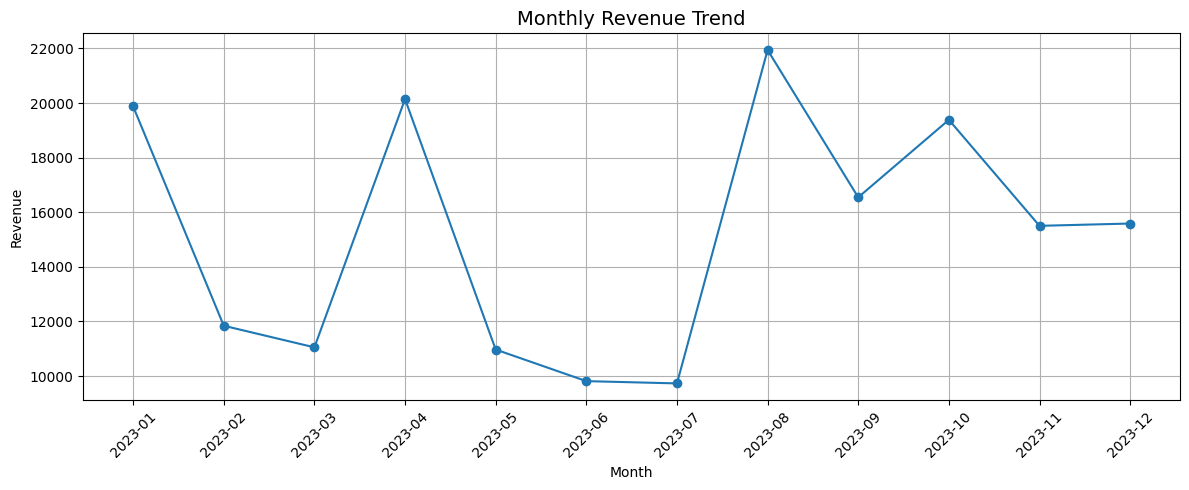

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_revenue.index.astype(str),
         monthly_revenue.values,
         marker='o')

plt.title("Monthly Revenue Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


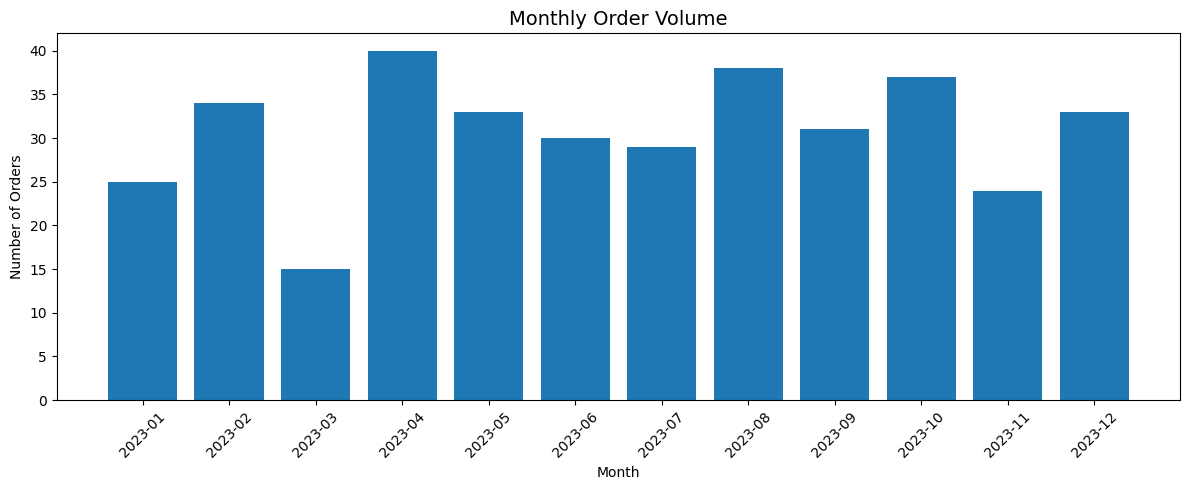

In [49]:
plt.figure(figsize=(12, 5))

plt.bar(monthly_orders.index.astype(str),
        monthly_orders.values)

plt.title("Monthly Order Volume", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


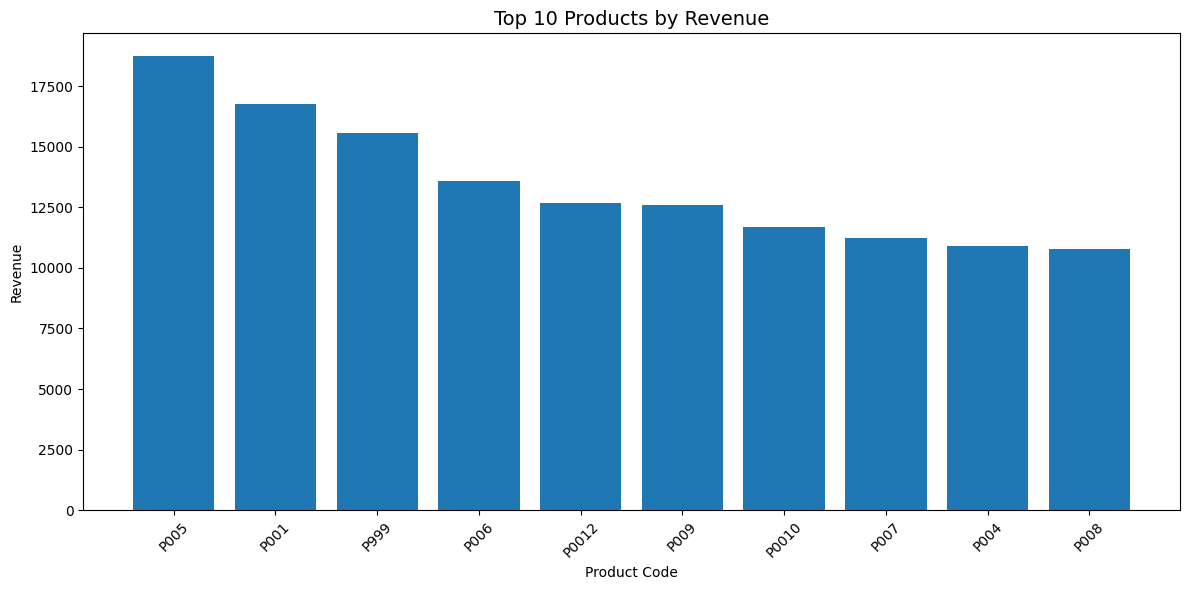

In [50]:
top_products = revenue_by_product.sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

plt.bar(top_products.index.astype(str),
        top_products.values)

plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Product Code")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


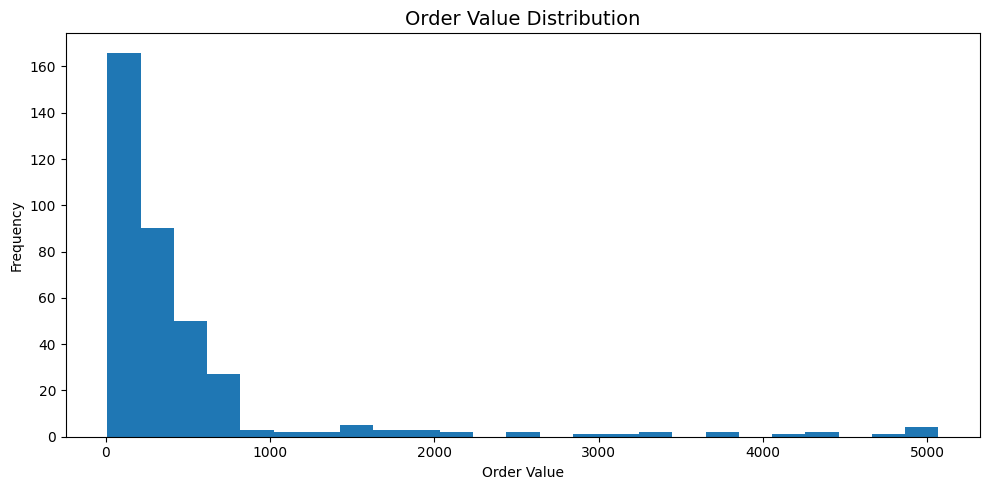

In [51]:
plt.figure(figsize=(10, 5))

plt.hist(fact_sales['revenue'], bins=25)

plt.title("Order Value Distribution", fontsize=14)
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



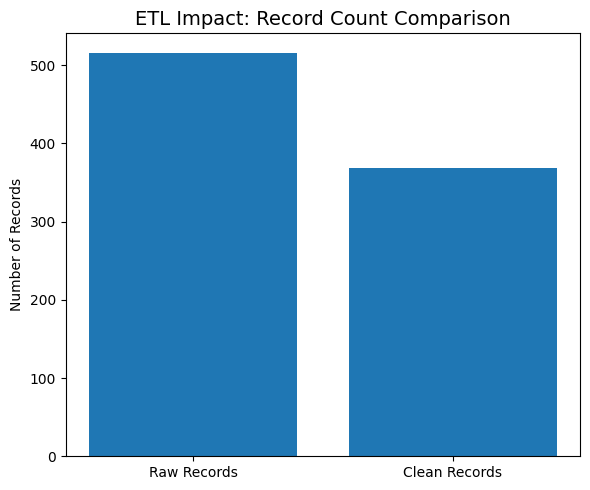

In [52]:
plt.figure(figsize=(6, 5))

plt.bar(['Raw Records', 'Clean Records'],
        [raw_count, len(fact_sales)])

plt.title("ETL Impact: Record Count Comparison", fontsize=14)
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()
